In [1]:
# Hemora_Thalassemia_Custom_CNN_Model.ipynb #

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile
import shutil
import pandas as pd
import seaborn as sns
from google.colab import drive
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight

# ==========================================
# 1. SETUP & DRIVE MOUNT
# ==========================================
print("Step 1: Mounting Google Drive...")
drive.mount('/content/drive')

# --- CONFIGURATION PATHS ---
ZIP_PATH = '/content/drive/MyDrive/Hemora Research Thalassemia Component/Data Set/thalassemia_dataset_new.zip'
RESULTS_DIR = '/content/drive/MyDrive/Hemora Research Thalassemia Component/Training Results/Custom_CNN_Model'

if not os.path.exists(RESULTS_DIR):
    os.makedirs(RESULTS_DIR)
    print(f"Created output directory: {RESULTS_DIR}")

# ==========================================
# 2. DATA EXTRACTION & MERGING
# ==========================================
print("\nStep 2: Extracting and Preparing Data...")
LOCAL_DATA_DIR = '/content/dataset/thalassemia_dataset'
if os.path.exists(LOCAL_DATA_DIR):
    shutil.rmtree('/content/dataset')

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

# Auto-Merge Logic for "Full Thalassemia" folder
thal_path = os.path.join(LOCAL_DATA_DIR, 'Thalassemia')
full_thal_path = os.path.join(LOCAL_DATA_DIR, 'Full Thalassemia')
if os.path.exists(full_thal_path):
    if not os.path.exists(thal_path): os.makedirs(thal_path)
    for filename in os.listdir(full_thal_path):
        src, dst = os.path.join(full_thal_path, filename), os.path.join(thal_path, filename)
        if os.path.isfile(src): shutil.move(src, dst)
    shutil.rmtree(full_thal_path)


Step 1: Mounting Google Drive...
Mounted at /content/drive
Created output directory: /content/drive/MyDrive/Hemora Research Thalassemia Component/Training Results/Custom_CNN_Model

Step 2: Extracting and Preparing Data...


In [2]:

# ==========================================
# 3. DATA PROCESSING & AUGMENTATION
# ==========================================
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    LOCAL_DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', subset='training', shuffle=True
)

validation_generator = train_datagen.flow_from_directory(
    LOCAL_DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', subset='validation', shuffle=False
)

# Class Imbalance Handling
cls_train = train_generator.classes
weights = compute_class_weight(class_weight='balanced', classes=np.unique(cls_train), y=cls_train)
class_weights = dict(zip(np.unique(cls_train), weights))


Found 2000 images belonging to 2 classes.
Found 499 images belonging to 2 classes.


In [3]:

# ==========================================
# 4. BUILD CUSTOM CNN ARCHITECTURE
# ==========================================
# This modular design allows for efficient feature extraction of cell abnormalities [cite: 153, 293]
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dropout(0.5), # Regularization to reduce false positives [cite: 222, 246]
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Binary output for Normal vs Thalassemia [cite: 253]
])

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
# ==========================================
# 5. CALLBACKS & TRAINING
# ==========================================
checkpoint = ModelCheckpoint(os.path.join(RESULTS_DIR, 'best_custom_cnn_model.h5'),
                             monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
csv_logger = CSVLogger(os.path.join(RESULTS_DIR, 'training_log_cnn.csv'), append=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

print("\n🚀 Training Custom CNN...")
history = model.fit(train_generator, validation_data=validation_generator,
                    epochs=15, class_weight=class_weights, callbacks=[checkpoint, csv_logger, reduce_lr])



🚀 Training Custom CNN...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4730 - loss: 0.6885
Epoch 1: val_accuracy improved from -inf to 0.58317, saving model to /content/drive/MyDrive/Hemora Research Thalassemia Component/Training Results/Custom_CNN_Model/best_custom_cnn_model.h5


63/63 ━━━━━━━━━━━━━━━━━━━━ 338s 5s/step - accuracy: 0.4733 - loss: 0.6884 - val_accuracy: 0.5832 - val_loss: 0.6723 - learning_rate: 1.0000e-04
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6682 - loss: 0.6188
Epoch 2: val_accuracy improved from 0.58317 to 0.73347, saving model to /content/drive/MyDrive/Hemora Research Thalassemia Component/Training Results/Custom_CNN_Model/best_custom_cnn_model.h5


63/63 ━━━━━━━━━━━━━━━━━━━━ 331s 5s/step - accuracy: 0.6692 - loss: 0.6179 - val_accuracy: 0.7335 - val_loss: 0.6038 - learning_rate: 1.0000e-04
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8167 - loss: 0.4257
Epoch 3: val_accuracy did not improve from 0.73347
63/63 ━━━━━━━━━━━━━━━━━━━━ 328s 5s/step - accuracy: 0.8166 - loss: 0.4257 - val_accuracy: 0.7194 - val_loss: 0.6253 - learning_rate: 1.0000e-04
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8310 - loss: 0.3758
Epoch 4: val_accuracy did not improve from 0.73347
63/63 ━━━━━━━━━━━━━━━━━━━━ 327s 5s/step - accuracy: 0.8309 - loss: 0.3759 - val_accuracy: 0.7335 - val_loss: 0.6817 - learning_rate: 1.0000e-04
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8253 - loss: 0.3907
Epoch 5: val_accuracy did not improve from 0.73347
63/63 ━━━━━━━━━━━━━━━━━━━━ 331s 5s/step - accuracy: 0.8253 - loss: 0.3906 - val_accuracy: 0.6914 - val_loss: 0.8581 - learning_rate: 1.0000e-04
Epoch 6/15
63/63 ━━━━━

63/63 ━━━━━━━━━━━━━━━━━━━━ 374s 5s/step - accuracy: 0.8410 - loss: 0.3785 - val_accuracy: 0.7355 - val_loss: 0.6955 - learning_rate: 2.0000e-05
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8179 - loss: 0.3726
Epoch 7: val_accuracy did not improve from 0.73547
63/63 ━━━━━━━━━━━━━━━━━━━━ 333s 5s/step - accuracy: 0.8181 - loss: 0.3724 - val_accuracy: 0.6934 - val_loss: 0.7698 - learning_rate: 2.0000e-05
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8310 - loss: 0.3721
Epoch 8: val_accuracy did not improve from 0.73547
63/63 ━━━━━━━━━━━━━━━━━━━━ 321s 5s/step - accuracy: 0.8311 - loss: 0.3719 - val_accuracy: 0.7234 - val_loss: 0.7280 - learning_rate: 2.0000e-05
Epoch 9/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8440 - loss: 0.3448
Epoch 9: val_accuracy did not improve from 0.73547
63/63 ━━━━━━━━━━━━━━━━━━━━ 332s 5s/step - accuracy: 0.8439 - loss: 0.3450 - val_accuracy: 0.7315 - val_loss: 0.7300 - learning_rate: 4.0000e-06
Epoch 10/15
63/63 ━━━━

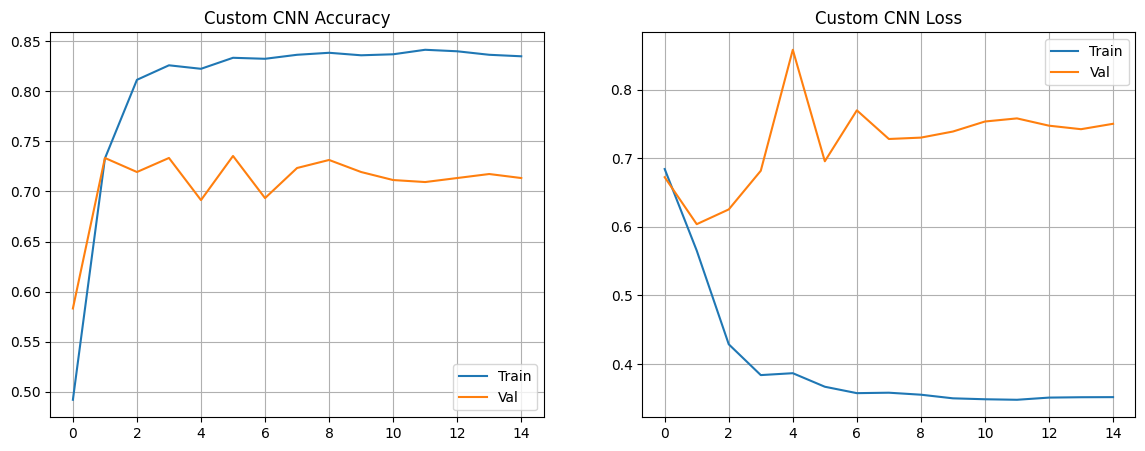

16/16 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step


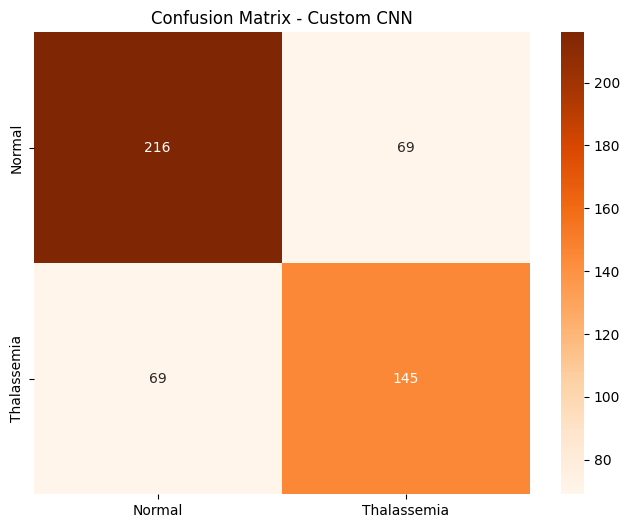

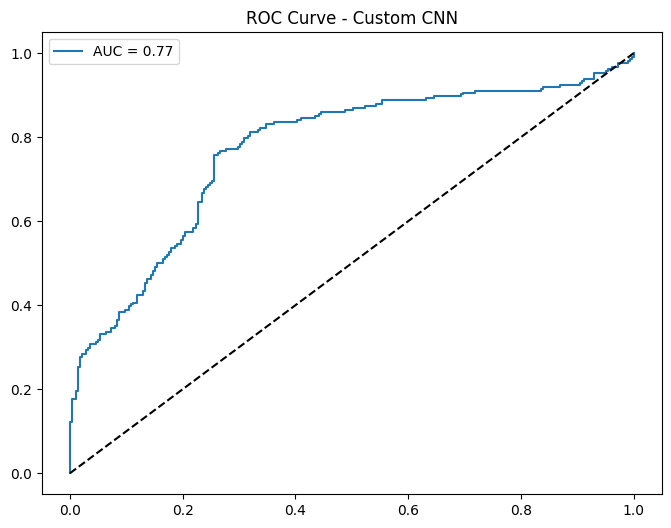

In [5]:

# ==========================================
# 6. METRICS & PLOTTING
# ==========================================
# Accuracy/Loss Charts [cite: 60, 62]
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1); plt.plot(history.history['accuracy'], label='Train'); plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Custom CNN Accuracy'); plt.legend(); plt.grid(True)
plt.subplot(1, 2, 2); plt.plot(history.history['loss'], label='Train'); plt.plot(history.history['val_loss'], label='Val')
plt.title('Custom CNN Loss'); plt.legend(); plt.grid(True)
plt.savefig(os.path.join(RESULTS_DIR, 'accuracy_loss_chart.png'))
plt.show()

# Confusion Matrix [cite: 63, 64]
validation_generator.reset()
y_true = validation_generator.classes
y_pred_prob = model.predict(validation_generator, steps=len(validation_generator))
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
class_labels = list(validation_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - Custom CNN')
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix.png'))
plt.show()

# ROC Curve [cite: 67]
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
plt.figure(figsize=(8, 6)); plt.plot(fpr, tpr, label=f'AUC = {auc(fpr, tpr):.2f}')
plt.plot([0, 1], [0, 1], 'k--'); plt.title('ROC Curve - Custom CNN'); plt.legend()
plt.savefig(os.path.join(RESULTS_DIR, 'roc_curve.png'))
plt.show()



Upload a Full Smear Image for Custom CNN analysis:


Saving T1-002.png to T1-002.png
Processing full smear: T1-002.png...
Found 212 potential objects. Analyzing cell morphology...


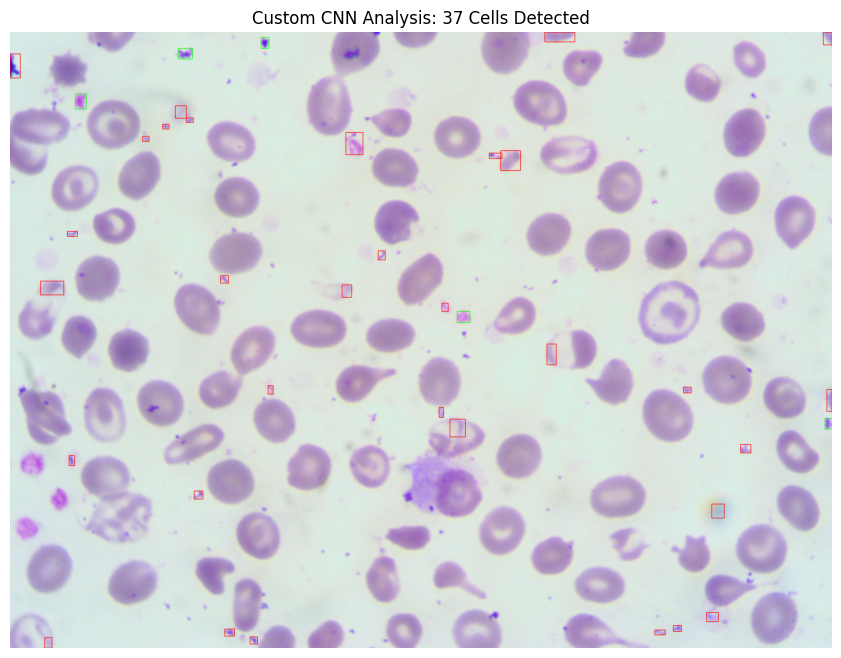

BETA-THALASSEMIA (MINOR) SCREENING REPORT
Total Red Blood Cells Analyzed: 37
Normal Morphology (Green):      5
Abnormal Morphology (Red):       32
Morphological Abnormality Ratio: 86.49%

>>> RESULT: POSITIVE indicators for Thalassemia Minor.
>>> RECOMMENDATION: Correlate with CBC indices (MCV, MCH).


In [7]:
# ==========================================
# 7. FULL SMEAR PIPELINE (Custom CNN Version)
# ==========================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import img_to_array
from google.colab import files

def analyze_full_smear_cnn(image_path, model):
    print(f"Processing full smear: {image_path}...")
    original_img = cv2.imread(image_path)
    if original_img is None:
        print("Error: Could not read image.")
        return
    output_img = original_img.copy()

    # 1. Segmentation (Isolating Red Blood Cells)
    gray = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    # Using Otsu's thresholding for automated cell isolation [cite: 49]
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    thal_count = 0
    normal_count = 0
    cells_analyzed = 0

    print(f"Found {len(contours)} potential objects. Analyzing cell morphology...")

    # 2. Iterate and Classify each cell [cite: 94]
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        # Filter noise and clumping based on area [cite: 49]
        if cv2.contourArea(cnt) < 500 or cv2.contourArea(cnt) > 6500:
            continue

        cells_analyzed += 1

        # Crop individual cell with padding
        cell_crop = original_img[max(0, y-5):min(original_img.shape[0], y+h+5),
                                 max(0, x-5):min(original_img.shape[1], x+w+5)]

        if cell_crop.size == 0: continue

        # Preprocessing for Custom CNN [cite: 40, 89]
        processed = cv2.resize(cv2.cvtColor(cell_crop, cv2.COLOR_BGR2RGB), (224, 224))
        processed = img_to_array(processed) / 255.0
        processed = np.expand_dims(processed, axis=0)

        # Deep Learning Prediction [cite: 92, 153]
        score = model.predict(processed, verbose=0)[0][0]

        # Identify morphological features (Microcytosis, Hypochromia, Target Cells) [cite: 95]
        if score > 0.5:
            color = (0, 0, 255) # Red for Thalassemia
            thal_count += 1
        else:
            color = (0, 255, 0) # Green for Normal
            normal_count += 1

        cv2.rectangle(output_img, (x, y), (x + w, y + h), color, 2)

    # 3. Visualization
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f"Custom CNN Analysis: {cells_analyzed} Cells Detected")
    plt.show()

    # 4. Final Clinical Reporting [cite: 104, 115]
    print("="*50)
    print("BETA-THALASSEMIA (MINOR) SCREENING REPORT")
    print("="*50)
    print(f"Total Red Blood Cells Analyzed: {cells_analyzed}") # [cite: 218]
    print(f"Normal Morphology (Green):      {normal_count}")
    print(f"Abnormal Morphology (Red):       {thal_count}") # [cite: 95]

    if cells_analyzed > 0:
        ratio = (thal_count / cells_analyzed) * 100
        print(f"Morphological Abnormality Ratio: {ratio:.2f}%")

        # Diagnostic threshold for minor detection based on smear features [cite: 257]
        if ratio > 5.0:
            print("\n>>> RESULT: POSITIVE indicators for Thalassemia Minor.") # [cite: 259]
            print(">>> RECOMMENDATION: Correlate with CBC indices (MCV, MCH).") # [cite: 258]
        else:
            print("\n>>> RESULT: NEGATIVE - Smear appears within normal limits.")
    print("="*50)

# --- EXECUTE ---
print("\nUpload a Full Smear Image for Custom CNN analysis:")
uploaded = files.upload()
if uploaded:
    fname = list(uploaded.keys())[0]
    analyze_full_smear_cnn(fname, model)